<h4>Gaussian equation and imports.</h4>

In [1]:
# import math functions
from math import *
import matplotlib.pyplot as plt
import numpy as np

# gaussian function
def f(mu, sigma2, x):
    ''' f takes in a mean and squared variance, and an input x
       and returns the gaussian value.'''
    coefficient = 1.0 / sqrt(2.0 * pi *sigma2)
    exponential = exp(-0.5 * (x-mu) ** 2 / sigma2)
    return coefficient * exponential
 

In [4]:
# the update function
def update(mean1, var1, mean2, var2):
    ''' This function takes in two means
        and two squared variance terms,
        and returns updated gaussian parameters.'''
    # Calculate the new parameters
    new_mean = (var2*mean1 + var1*mean2)/(var2+var1)
    new_var = 1/(1/var2 + 1/var1)
    
    return [new_mean, new_var]


# the motion update/predict function
def predict(mean1, var1, mean2, var2):
    ''' This function takes in two means
        and two squared variance terms,
        and returns updated gaussian parameters, 
        after motion.'''
    # Calculate the new parameters
    new_mean = mean1 + mean2
    new_var = var1 + var2
    return [new_mean, new_var]

In [5]:
# measurements for mu and motions, U
measurements = [5., 6., 7., 9., 10.]
motions = [1., 1., 2., 1., 1.]
# initial parameters
measurement_sig = 4. #r**2
motion_sig = 2. #u**2
mu = 0.
sig = 10000.
## loop through all measurements/motions
## print out and display the resulting Gaussian 
for i in range(len(motions)):
    mu,sig = update(mu,sig, measurements[i],measurement_sig)
    print(f'Update:  {[mu,sig]}')
    mu,sig = predict(mu,sig, motions[i],motion_sig)
    print(f'Predict: {[mu,sig]}')

Update:  [4.998000799680128, 3.9984006397441023]
Predict: [5.998000799680128, 5.998400639744102]
Update:  [5.999200191953932, 2.399744061425258]
Predict: [6.999200191953932, 4.399744061425258]
Update:  [6.999619127420922, 2.0951800575117594]
Predict: [8.999619127420921, 4.09518005751176]
Update:  [8.999811802788143, 2.0235152416216957]
Predict: [9.999811802788143, 4.023515241621696]
Update:  [9.999906177177365, 2.0058615808441944]
Predict: [10.999906177177365, 4.005861580844194]


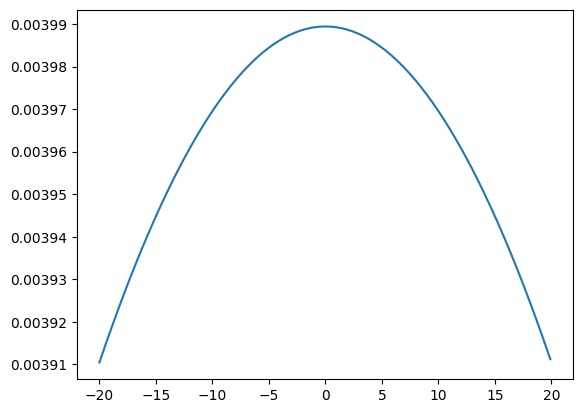

In [6]:
# display the *initial* gaussian over a range of x values
# define the parameters
mu_old = 0
sigma_old = 10000

# define a range of x values
x_axis = np.arange(-20, 20, 0.1)

# create a corresponding list of gaussian values
g = []
for x in x_axis:
    g.append(f(mu_old, sigma_old, x))

plt.plot(x_axis, g)

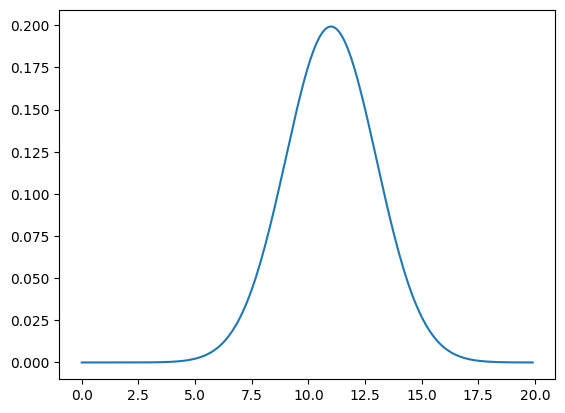

In [7]:
n = []

# define a range of x values
x_axis = np.arange(0, 20, 0.1)

for x in x_axis:
    n.append(f(mu, sig, x))
# plot the result 
plt.plot(x_axis, n)